In [2]:
import sys
sys.path.append('../src')

import absl.logging
absl.logging.set_verbosity(absl.logging.ERROR)

import matplotlib.pyplot as plt
plt.style.core.USER_LIBRARY_PATHS.append('/gscratch/matsulab/utils/ctleelab-mpl-utilities/ctleelab_plothelper')
plt.style.reload_library()

sys.path.append('../../../utils')
from fonts.mpl_fonts import set_arial_font
set_arial_font()

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

[mpl_fonts] Using font: Arial
[mpl_fonts] Font dir: /mmfs1/gscratch/matsulab/utils/fonts


In [16]:
## To reload

import importlib
import pinn.normal_curves as normal_curves
importlib.reload(normal_curves)

import pinn.plot as plot
importlib.reload(plot)

<module 'pinn.plot' from '/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/notebooks/../src/pinn/plot.py'>

### Calculate normal, curvature, and force

In [4]:
from pinn.normal_curves import write_vtk_polydata, calc_norm_curv_K_force

import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints

# ==== Parameters =====
lambda_1 = 100000
lambda_2 = 1
lambda_3 = 100000
step = 10000
# hidden_dim = 128
phase = 2

# #### Parameter for golgi ####
# data_id = "czii_27042022"
# shape = "golgi_01"
# N_voxel = 512
# voxel_size = 0.784 # nm
# half_length = N_voxel * voxel_size / 2.0
# x_range = (-0.4, 0.38) # this is written in scale-less unit
# y_range = (-0.9, 1.0)
# z_range = (-0.9, 0.9)
# lambda_4 = 0.1

#### Parameter for mito ####
data_id = "mendelsohn_2021"
shape = "mito_01"
N_voxel = 360
voxel_size = 1.64 # nm
half_length = N_voxel * voxel_size / 2.0
x_range = None
y_range = None
z_range = None
lambda_4 = 0.01


# for phase in [0,1,2]:
# for phase in [2]:
for hidden_dim in [8, 16, 32, 64, 128]:

    if phase == 0:
        _lambda_2 = 0
        _lambda_4 = 0
    elif phase == 1:
        _lambda_2 = lambda_2
        _lambda_4 = 0
    elif phase == 2:
        _lambda_2 = lambda_2
        _lambda_4 = lambda_4
        
    # ==== Load checkpoint data =====
    checkpoint_dir = f"../outputs/logs/{data_id}/{shape}_{hidden_dim}/phase{phase}_{lambda_1}_{_lambda_2}_{lambda_3}_{_lambda_4}"
    checkpoint_path = os.path.abspath(f"{checkpoint_dir}/checkpoint_{step}")
    checkpoint_data = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)
    print(checkpoint_path)
    
    # ==== Calculate quantities =====
    verts, faces, norms, theta, curvs, gauss, force = calc_norm_curv_K_force(checkpoint_data, x_range=x_range,
                                                                             y_range=y_range, z_range=z_range,
                                                                             half_length=half_length, hidden_dim=hidden_dim)
    
    ## ==== Save NPZ =====
    npz_path = f"{checkpoint_dir}/verts_{step}.npz"
    np.savez(npz_path, verts=verts, faces=faces, norms=norms, theta = theta, curvs=curvs, gauss=gauss, force=force)

    ## ==== Save VTK =====
    vtk_path = f"{checkpoint_dir}/verts_{step}.vtk"
    write_vtk_polydata(vtk_path, verts, faces,
                       point_vectors={"Normal": norms, "Force": force},
                       point_scalars={"MeanCurvature": curvs, "GaussianCurvature": gauss, "Angle": theta})

/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/mendelsohn_2021/mito_01_8/phase2_100000_1_100000_0.01/checkpoint_10000
/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/mendelsohn_2021/mito_01_16/phase2_100000_1_100000_0.01/checkpoint_10000
/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/mendelsohn_2021/mito_01_32/phase2_100000_1_100000_0.01/checkpoint_10000
/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/mendelsohn_2021/mito_01_64/phase2_100000_1_100000_0.01/checkpoint_10000
/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/mendelsohn_2021/mito_01_128/phase2_100000_1_100000_0.01/checkpoint_10000


### Plot output

/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/mendelsohn_2021/mito_01_128/phase1_100000_1_100000_0/checkpoint_10000


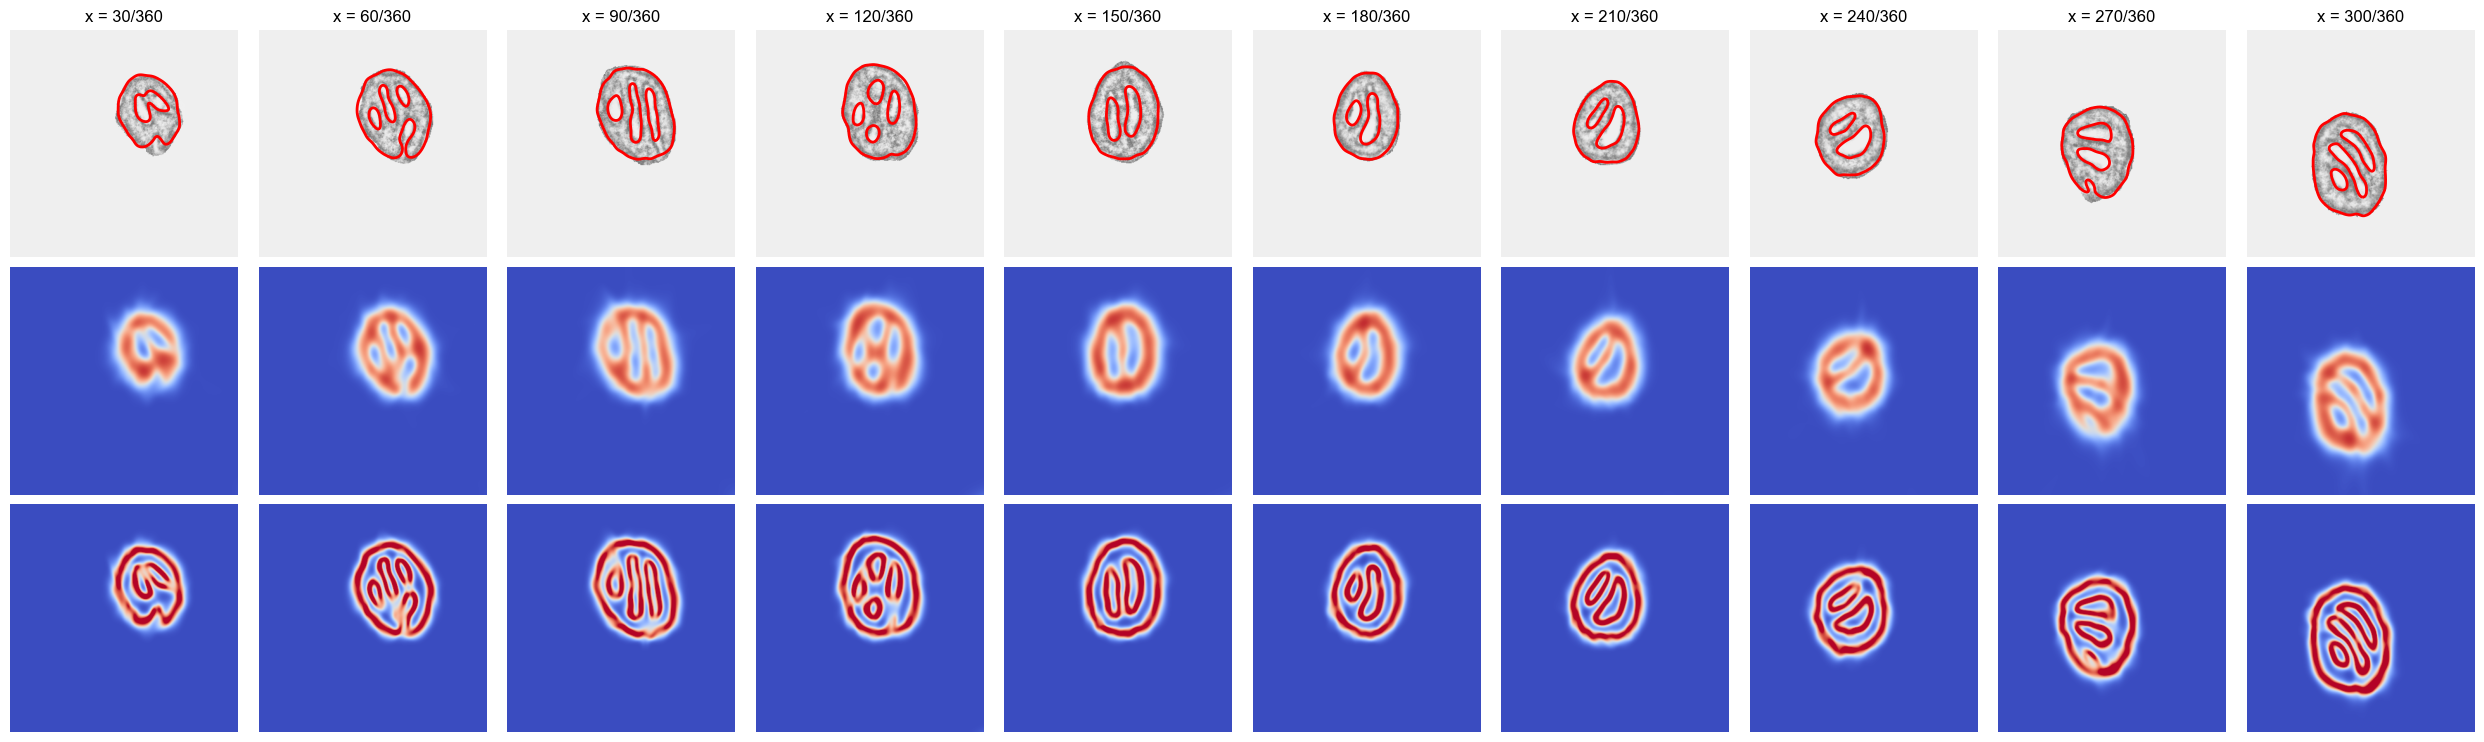

In [17]:
from pinn.plot import visualize_cryoET_with_contours, visualize_phase
import mrcfile
import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints

# ==== Parameters =====
lambda_1 = 100000
lambda_2 = 1
lambda_3 = 100000
lambda_4 = 0.1
step = 10000
hidden_dim = 
phase = 1
axis = "x"

# ==== Parameters for Golgi =====
# data_id = "czii_27042022"
# shape = "golgi_01"
# slices = list(range(40, 91, 10))

# ==== Parameters for Mito =====
data_id = "mendelsohn_2021"
shape = "mito_01"
slices = list(range(30, 301, 30))
# slices = [100, 150, 200, 250, 300]


if phase == 0:
    _lambda_2 = 0
    _lambda_4 = 0
elif phase == 1:
    _lambda_2 = lambda_2
    _lambda_4 = 0
elif phase == 2:
    _lambda_2 = lambda_2
    _lambda_4 = lambda_4

# ==== Load checkpoint data =====
checkpoint_dir = f"../outputs/logs/{data_id}/{shape}_{hidden_dim}/phase{phase}_{lambda_1}_{_lambda_2}_{lambda_3}_{_lambda_4}"
checkpoint_path = os.path.abspath(f"{checkpoint_dir}/checkpoint_{step}")
checkpoint_data = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)
print(checkpoint_path)

# ===== Load cryoET data =====
mrc_file_path = f"../data/experimental/vol/formatted/{data_id}/{shape}.mrc"
with mrcfile.open(mrc_file_path, permissive=True) as mrc:
    cryoET_data = mrc.data
# cryoET_data = 1 - cryoET_data
grid_size = cryoET_data.shape[0]

# ==== Plot output =====
n = len(slices)
fig, axes = plt.subplots(3, n, figsize=(2.5*n, 2.5*3))

# --- row 1: cryoET + contour ---
for ax, slice_index in zip(axes[0], slices):
    visualize_cryoET_with_contours(
        ax, step, checkpoint_data, cryoET_data, grid_size=grid_size, 
        slice_index=slice_index, axis=axis, no_label=True, 
    )
    ax.set_title(f"{axis} = {slice_index}/{grid_size}")

# --- row 2: phi ---
for ax, slice_index in zip(axes[1], slices):
    visualize_phase(
        ax, epsilon=0.05, checkpoint=checkpoint_data, component="phi", grid_size=grid_size,
        slice_index=slice_index, axis=axis, no_label=True, vmin=-1, vmax=1, 
    )

# --- row 3: tension ---
for ax, slice_index in zip(axes[2], slices):
    visualize_phase(
        ax, epsilon=0.05, checkpoint=checkpoint_data, component="tension", grid_size=grid_size,
        slice_index=slice_index, axis=axis, no_label=True, vmin=0.0, vmax=1.0, 
    )

plt.tight_layout()
plt.show()